Saving RQ2.csv to RQ2 (4).csv
Loaded file: RQ2 (4).csv
Shape: (72, 15)

Columns:
['id', 'specification', 'Task', 'passed_tests_phase1', 'failed_tests_phase1', 'num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1', 'passed_tests_phase2', 'failed_tests_phase2', 'num_hidden_test_passed_phase2', 'num_hidden_test_failed_phase2', 'binary_status', 'pass_to_pass', 'pass_to_fail', 'percent_pass_to_fail']

CHECKING AGAINST PRECOMPUTED COLUMNS IN YOUR CSV
pass_to_pass matches: True
pass_to_fail matches: True
percent_pass_to_fail matches: True

SUMMARY BY SPECIFICATION
  specification   n  mean_pass_to_pass  sd_pass_to_pass  \
0            G1  24          11.375000         2.318405   
1            G2  24          12.958333         2.440227   
2            G3  24          21.458333         8.145306   

   mean_regression_count  sd_regression_count  regression_probability  \
0               0.083333             0.282330                0.083333   
1               0.375000             1.636

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


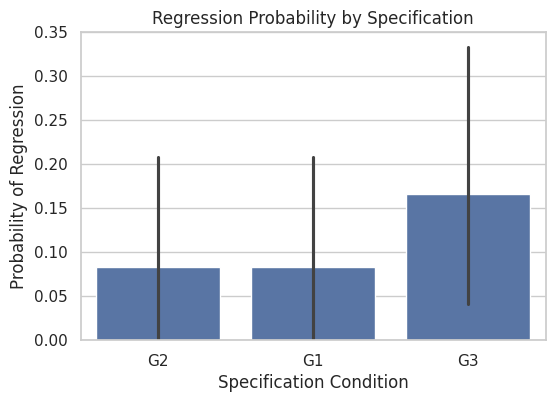

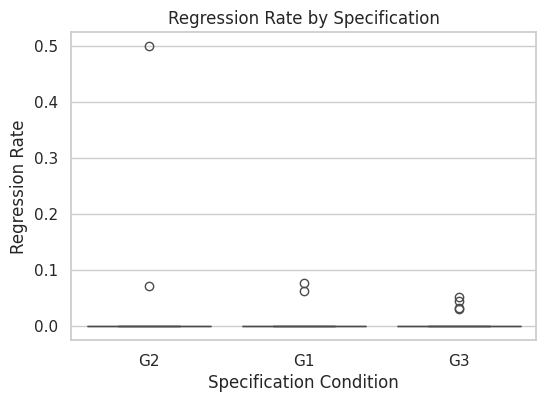

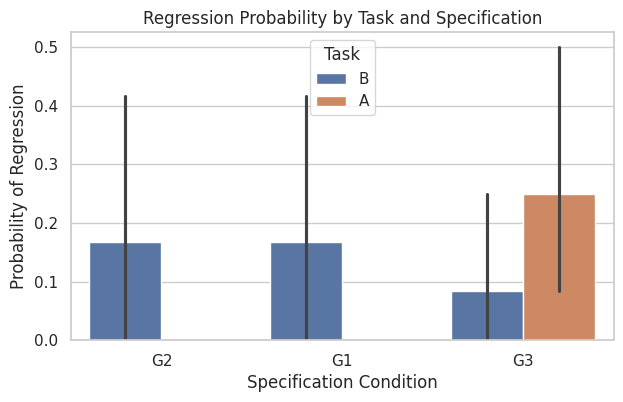

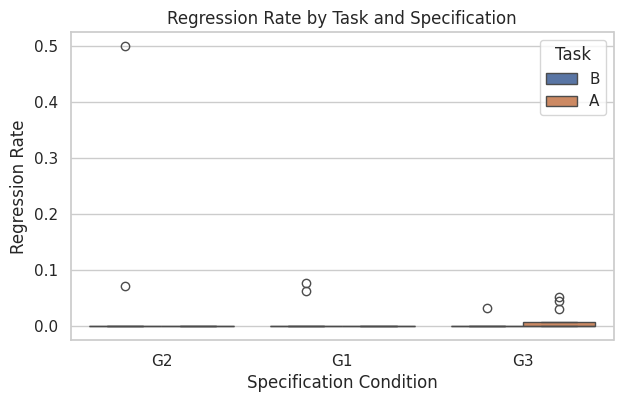

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# RQ2 Analysis Notebook for Google Colab
# Adjusted to your CSV schema
# =========================================================

# !pip -q install pandas numpy scipy statsmodels matplotlib seaborn

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import files
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set(style="whitegrid")

# =========================================================
# 1. Upload CSV
# =========================================================
# uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Loaded file:", filename)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# =========================================================
# 2. Helper: parse list-like columns
# =========================================================
def parse_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

# Parse the actual columns from your CSV
df["phase1_passed_list"] = df["passed_tests_phase1"].apply(parse_list)
df["phase2_passed_list"] = df["passed_tests_phase2"].apply(parse_list)

# =========================================================
# 3. Recompute regression metrics from scratch
# =========================================================
# Regression = test passed in Phase 1 but failed in Phase 2
regression_tests = []
pass_to_pass_calc = []
pass_to_fail_calc = []
binary_regression_calc = []
regression_rate_calc = []

for _, row in df.iterrows():
    p1 = set(row["phase1_passed_list"])
    p2 = set(row["phase2_passed_list"])

    pass_to_pass = len(p1.intersection(p2))
    regressions = len(p1 - p2)  # pass in P1, fail in P2

    pass_to_pass_calc.append(pass_to_pass)
    pass_to_fail_calc.append(regressions)
    regression_tests.append(sorted(list(p1 - p2)))
    binary_regression_calc.append(1 if regressions > 0 else 0)

    if len(p1) > 0:
        regression_rate_calc.append(regressions / len(p1))
    else:
        regression_rate_calc.append(np.nan)

df["pass_to_pass_calc"] = pass_to_pass_calc
df["pass_to_fail_calc"] = pass_to_fail_calc
df["binary_regression_calc"] = binary_regression_calc
df["regression_rate_calc"] = regression_rate_calc
df["regression_tests"] = regression_tests

# =========================================================
# 4. Compare with your precomputed columns
# =========================================================
print("\n===================================================")
print("CHECKING AGAINST PRECOMPUTED COLUMNS IN YOUR CSV")
print("===================================================")

if "pass_to_pass" in df.columns:
    print("pass_to_pass matches:",
          np.allclose(df["pass_to_pass"], df["pass_to_pass_calc"], equal_nan=True))

if "pass_to_fail" in df.columns:
    print("pass_to_fail matches:",
          np.allclose(df["pass_to_fail"], df["pass_to_fail_calc"], equal_nan=True))

if "percent_pass_to_fail" in df.columns:
    pct_from_calc = df["regression_rate_calc"] * 100
    print("percent_pass_to_fail matches:",
          np.allclose(df["percent_pass_to_fail"], pct_from_calc, equal_nan=True))

# =========================================================
# 5. Core summary tables
# =========================================================
print("\n===================================================")
print("SUMMARY BY SPECIFICATION")
print("===================================================")

summary_spec = df.groupby("specification").agg(
    n=("specification", "count"),
    mean_pass_to_pass=("pass_to_pass_calc", "mean"),
    sd_pass_to_pass=("pass_to_pass_calc", "std"),
    mean_regression_count=("pass_to_fail_calc", "mean"),
    sd_regression_count=("pass_to_fail_calc", "std"),
    regression_probability=("binary_regression_calc", "mean"),
    mean_regression_rate=("regression_rate_calc", "mean"),
    sd_regression_rate=("regression_rate_calc", "std")
).reset_index()

print(summary_spec)

print("\n===================================================")
print("COUNT OF PARTICIPANTS WITH >=1 REGRESSION")
print("===================================================")
print(df.groupby("specification")["binary_regression_calc"].sum())

# =========================================================
# 6. Task-specific summary
# =========================================================
print("\n===================================================")
print("SUMMARY BY SPECIFICATION AND TASK")
print("===================================================")

summary_task = df.groupby(["specification", "Task"]).agg(
    n=("specification", "count"),
    mean_regression_count=("pass_to_fail_calc", "mean"),
    sd_regression_count=("pass_to_fail_calc", "std"),
    regression_probability=("binary_regression_calc", "mean"),
    mean_regression_rate=("regression_rate_calc", "mean"),
    sd_regression_rate=("regression_rate_calc", "std")
).reset_index()

print(summary_task)

# =========================================================
# 7. ANOVA on regression count and regression rate
# =========================================================
print("\n===================================================")
print("ANOVA: REGRESSION COUNT")
print("===================================================")

model_R = ols("pass_to_fail_calc ~ C(specification)", data=df).fit()
anova_R = sm.stats.anova_lm(model_R, typ=2)
print(anova_R)

print("\n===================================================")
print("ANOVA: REGRESSION RATE")
print("===================================================")

model_RR = ols("regression_rate_calc ~ C(specification)", data=df).fit()
anova_RR = sm.stats.anova_lm(model_RR, typ=2)
print(anova_RR)

# =========================================================
# 8. Tukey post-hoc tests
# =========================================================
print("\n===================================================")
print("TUKEY HSD: REGRESSION COUNT")
print("===================================================")
tukey_R = pairwise_tukeyhsd(df["pass_to_fail_calc"], df["specification"])
print(tukey_R)

print("\n===================================================")
print("TUKEY HSD: REGRESSION RATE")
print("===================================================")
tukey_RR = pairwise_tukeyhsd(df["regression_rate_calc"], df["specification"])
print(tukey_RR)

# =========================================================
# 9. Logistic regression for binary regression occurrence
# =========================================================
print("\n===================================================")
print("LOGISTIC REGRESSION: BINARY REGRESSION OCCURRENCE")
print("===================================================")

logit_model = logit("binary_regression_calc ~ C(specification)", data=df).fit(disp=False)
print(logit_model.summary())

print("\nOdds Ratios:")
print(np.exp(logit_model.params))

# =========================================================
# 10. Task-specific logistic regression
# =========================================================
for task_name in sorted(df["Task"].unique()):
    print("\n===================================================")
    print(f"LOGISTIC REGRESSION FOR TASK {task_name}")
    print("===================================================")

    df_task = df[df["Task"] == task_name].copy()
    try:
        task_model = logit("binary_regression_calc ~ C(specification)", data=df_task).fit(disp=False)
        print(task_model.summary())
        print("\nOdds Ratios:")
        print(np.exp(task_model.params))
    except Exception as e:
        print("Model could not be fit:", e)

# =========================================================
# 11. Combined model with Task as blocking factor
# =========================================================
print("\n===================================================")
print("COMBINED LOGISTIC MODEL WITH TASK AS BLOCKING FACTOR")
print("===================================================")

try:
    combined_model = logit("binary_regression_calc ~ C(specification) + C(Task)", data=df).fit(disp=False)
    print(combined_model.summary())
    print("\nOdds Ratios:")
    print(np.exp(combined_model.params))
except Exception as e:
    print("Combined model could not be fit:", e)

# =========================================================
# 12. Visualizations
# =========================================================

# A. Regression probability by specification
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="specification", y="binary_regression_calc", errorbar=("ci", 95))
plt.ylabel("Probability of Regression")
plt.xlabel("Specification Condition")
plt.title("Regression Probability by Specification")
plt.show()

# B. Regression rate by specification
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="specification", y="regression_rate_calc")
plt.ylabel("Regression Rate")
plt.xlabel("Specification Condition")
plt.title("Regression Rate by Specification")
plt.show()

# C. Regression probability by task and specification
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="specification", y="binary_regression_calc", hue="Task", errorbar=("ci", 95))
plt.ylabel("Probability of Regression")
plt.xlabel("Specification Condition")
plt.title("Regression Probability by Task and Specification")
plt.show()

# D. Regression rate by task and specification
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="specification", y="regression_rate_calc", hue="Task")
plt.ylabel("Regression Rate")
plt.xlabel("Specification Condition")
plt.title("Regression Rate by Task and Specification")
plt.show()

# =========================================================
# 13. Optional: export cleaned analysis table
# =========================================================
df.to_csv("RQ2_cleaned_analysis_output.csv", index=False)
files.download("RQ2_cleaned_analysis_output.csv")

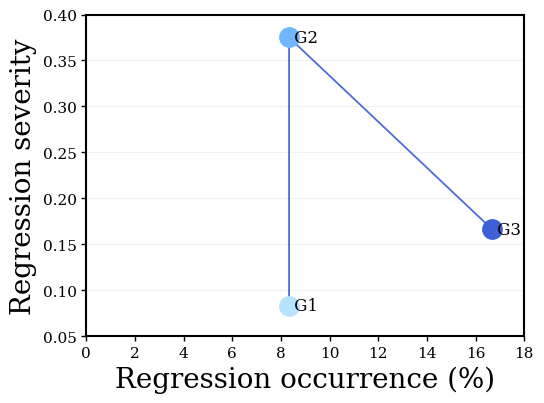

In [31]:
# ==========================================
# RQ2: Regression Occurrence vs Severity
# FINAL (White background, ASE-ready)
# ==========================================

# from google.colab import files
# uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
# filename = list(uploaded.keys())[0]
df = pd.read_csv("Datasets/RQ2.csv")

group_col = "specification"
fail_col = "pass_to_fail"

# -----------------------------
# Compute metrics
# -----------------------------
df[group_col] = df[group_col].astype(str).str.strip()
df["regression_binary"] = (df[fail_col] > 0).astype(int)

agg = (
    df.groupby(group_col, as_index=False)
      .agg(
          regression_occurrence=("regression_binary", "mean"),
          regression_severity=(fail_col, "mean")
      )
)

agg["regression_occurrence"] *= 100

order = ["G1", "G2", "G3"]
agg[group_col] = pd.Categorical(agg[group_col], categories=order, ordered=True)
agg = agg.sort_values(group_col)

# -----------------------------
# Style
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,

    # 🔥 FORCE WHITE BACKGROUND
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"
})

colors = {
    "G1": "#b7e3ff",
    "G2": "#6fb6ff",
    "G3": "#3f5fd7"
}

line_color = "#4f6bd8"

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.6, 4.2))

for _, row in agg.iterrows():
    g = row[group_col]
    x = row["regression_occurrence"]
    y = row["regression_severity"]

    ax.scatter(
        x, y,
        s=190,
        color=colors[g],
        edgecolor=colors[g],
        linewidth=1.2,
        zorder=3
    )

    ax.text(
        x, y,
        f" {g}",
        fontsize=12,
        va="center",
        ha="left",
        color="black"
    )

ax.plot(
    agg["regression_occurrence"],
    agg["regression_severity"],
    color=line_color,
    linewidth=1.3,
    zorder=2
)

ax.set_xlabel("Regression occurrence (%)", fontsize = 20)
ax.set_ylabel("Regression severity", fontsize = 20)

ax.set_xlim(0, 18)
ax.set_ylim(0.05,0.4)

ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.12, color="gray")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', colors='black', width=1.0)

plt.tight_layout()

# -----------------------------
# Save PDF (WHITE)
# -----------------------------
output_pdf = "RQ2_occurrence_severity_final.pdf"
fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.show()
# files.download(output_pdf)

Columns: ['id', 'specification', 'Task', 'passed_tests_phase1', 'failed_tests_phase1', 'num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1', 'passed_tests_phase2', 'failed_tests_phase2', 'num_hidden_test_passed_phase2', 'num_hidden_test_failed_phase2', 'binary_status', 'pass_to_pass', 'pass_to_fail', 'percent_pass_to_fail']
                           Logit Regression Results                           
Dep. Variable:      regression_binary   No. Observations:                   72
Model:                          Logit   Df Residuals:                       69
Method:                           MLE   Df Model:                            2
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                 0.02127
Time:                        00:47:22   Log-Likelihood:                -24.582
converged:                       True   LL-Null:                       -25.116
Covariance Type:            nonrobust   LLR p-value:                    0.5861
                              

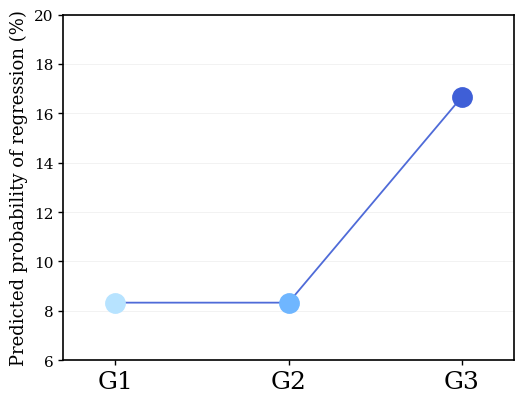

In [30]:
# ==========================================
# Combined Predicted Probability of Regression
# Tasks A + B together
# Output: RQ2_predicted_probability_combined.pdf
# ==========================================

# from google.colab import files
# uploaded = files.upload()   # upload your CSV here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -----------------------------
# 1. Load uploaded file
# -----------------------------
# filename = list(uploaded.keys())[0]
df = pd.read_csv("Datasets/RQ2.csv")

# print("Loaded:", filename)
print("Columns:", list(df.columns))

# -----------------------------
# 2. Required columns
# -----------------------------
required_cols = ["specification", "pass_to_fail"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -----------------------------
# 3. Build binary regression variable
# -----------------------------
df = df.copy()
df["specification"] = df["specification"].astype(str).str.strip()

# 1 if any regression occurred, else 0
df["regression_binary"] = (df["pass_to_fail"] > 0).astype(int)

# Keep only expected groups
order = ["G1", "G2", "G3"]
df = df[df["specification"].isin(order)].copy()

# -----------------------------
# 4. Logistic regression
# G1 is reference
# -----------------------------
model = smf.logit("regression_binary ~ C(specification, Treatment(reference='G1'))", data=df).fit(disp=False)

print(model.summary())

# -----------------------------
# 5. Predicted probabilities for G1, G2, G3
# -----------------------------
pred_df = pd.DataFrame({"specification": order})
pred_df["predicted_probability"] = model.predict(pred_df)

print("\nPredicted probabilities:")
print(pred_df)

# Convert to percent if you prefer
pred_df["predicted_probability_pct"] = pred_df["predicted_probability"] * 100

# -----------------------------
# 6. Styling (match previous figures)
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 18,
    "ytick.labelsize": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42
})

colors = {
    "G1": "#b7e3ff",
    "G2": "#6fb6ff",
    "G3": "#3f5fd7"
}

line_color = "#4f6bd8"

# -----------------------------
# 7. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5.4, 4.2))

x_positions = [1, 2, 3]
y_values = pred_df["predicted_probability_pct"].values

# line
ax.plot(
    x_positions,
    y_values,
    color=line_color,
    linewidth=1.3,
    zorder=2
)

# points
for x, (_, row) in zip(x_positions, pred_df.iterrows()):
    g = row["specification"]
    y = row["predicted_probability_pct"]

    ax.scatter(
        x, y,
        s=190,
        color=colors[g],
        edgecolor=colors[g],
        linewidth=1.2,
        zorder=3
    )

    ax.text(
        x, y,
        "",
        fontsize=12,
        va="center",
        ha="left",
        color="black"
    )

# -----------------------------
# 8. Axes
# -----------------------------
ax.set_xticks(x_positions)
ax.set_xticklabels(order)
ax.set_xlabel("")
ax.set_ylabel("Predicted probability of regression (%)", fontsize=13)

ax.set_xlim(0.7, 3.3)
ax.set_ylim(6, 20)

# -----------------------------
# 9. Grid and full box frame
# -----------------------------
ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.12, color="gray")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.tick_params(axis='both', colors='black', width=1.0)

plt.tight_layout()

# -----------------------------
# 10. Save PDF
# -----------------------------
output_pdf = "RQ2_predicted_probability_combined.pdf"
fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.show()
# files.download(output_pdf)